# RideWise — Feature Engineering

Build a rich feature table using RFM, behavioural, session, and temporal signals.

## Step 1 · Setup & Load

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

PALETTE = ["#2D6A4F", "#52B788", "#95D5B2", "#D8F3DC", "#B7E4C7"]
RED     = "#E76F51"
ORANGE  = "#E9C46A"
sns.set_theme(style="whitegrid", font_scale=1.2)

DATA_PROCESSED = os.path.join("..", "processed")

riders   = pd.read_csv(os.path.join(DATA_PROCESSED, "riders_clean.csv"),   parse_dates=["signup_date"])
drivers  = pd.read_csv(os.path.join(DATA_PROCESSED, "drivers_clean.csv"))
trips    = pd.read_csv(os.path.join(DATA_PROCESSED, "trips_clean.csv"),     parse_dates=["pickup_time","dropoff_time"])
sessions = pd.read_csv(os.path.join(DATA_PROCESSED, "sessions_clean.csv"), parse_dates=["session_time"])

reference_date = trips["pickup_time"].max()
print(f"Reference date : {reference_date.date()}")
print(f"Riders         : {len(riders):,}")
print(f"Trips          : {len(trips):,}")
print(f"Sessions       : {len(sessions):,}")


Reference date : 2025-04-27
Riders         : 10,000
Trips          : 200,000
Sessions       : 50,000


## Step 2 · Eligible Riders

Include only riders with ≥1 trip and account age ≥ 60 days.

In [2]:
riders["account_age_days"] = (reference_date - riders["signup_date"]).dt.days
riders_with_trips = set(trips["user_id"])

eligible = riders[
    riders["user_id"].isin(riders_with_trips) &
    (riders["account_age_days"] >= 60)
][["user_id", "churned"]].copy()

print(f"Total riders   : {len(riders):,}")
print(f"Eligible riders: {len(eligible):,}")
print(f"Churn rate     : {eligible['churned'].mean() * 100:.1f}%")


Total riders   : 10,000
Eligible riders: 9,204
Churn rate     : 10.7%


## Step 3 · RFM Features
### 3a · Recency

In [3]:
last_trip = (trips.groupby("user_id")["pickup_time"].max().reset_index(name="last_trip"))
last_session = (sessions.groupby("rider_id")["session_time"].max()
                .reset_index().rename(columns={"session_time":"last_session","rider_id":"user_id"}))

recency = (eligible[["user_id"]]
           .merge(last_trip,    on="user_id", how="left")
           .merge(last_session, on="user_id", how="left"))

recency["days_since_last_trip"]    = (reference_date - recency["last_trip"]).dt.days.fillna(999)
recency["days_since_last_session"] = (reference_date - recency["last_session"]).dt.days.fillna(999)
recency = recency[["user_id","days_since_last_trip","days_since_last_session"]]
recency.head()


,user_id,days_since_last_trip,days_since_last_session
0,R00000,25,0.0
1,R00001,5,0.0
2,R00002,14,0.0
3,R00004,12,0.0
4,R00005,2,0.0


### 3b · Frequency

In [4]:
frequency = eligible[["user_id"]].copy()

for days in [7, 30, 60, 90]:
    cutoff = reference_date - pd.Timedelta(days=days)
    counts = (trips[trips["pickup_time"] >= cutoff]
              .groupby("user_id").size()
              .reset_index(name=f"trips_last_{days}d"))
    frequency = frequency.merge(counts, on="user_id", how="left")

freq_cols = [f"trips_last_{d}d" for d in [7, 30, 60, 90]]
frequency[freq_cols] = frequency[freq_cols].fillna(0).astype(int)
frequency.head()


,user_id,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d
0,R00000,0,1,1,3
1,R00001,1,2,3,3
2,R00002,0,1,4,5
3,R00004,0,2,2,5
4,R00005,1,2,2,4


### 3c · Monetary

In [5]:
monetary = (trips.groupby("user_id")
            .agg(monetary_total=("total_revenue","sum"),
                 monetary_avg  =("total_revenue","mean"),
                 trips_lifetime=("trip_id","count"))
            .round(2).reset_index())

cutoff_30   = reference_date - pd.Timedelta(days=30)
monetary_30 = (trips[trips["pickup_time"] >= cutoff_30]
               .groupby("user_id")["total_revenue"].sum()
               .reset_index(name="monetary_last_30d"))

monetary = monetary.merge(monetary_30, on="user_id", how="left")
monetary["monetary_last_30d"] = monetary["monetary_last_30d"].fillna(0)
monetary.head()


,user_id,monetary_total,monetary_avg,trips_lifetime,monetary_last_30d
0,R00000,414.13,16.57,25,16.310
1,R00001,195.69,13.98,14,26.830
2,R00002,482.94,20.12,24,14.900
3,R00003,146.15,16.24,9,0.000
4,R00004,391.15,24.45,16,45.718


### 3d · RFM Scores (1–5 quantile bins)

In [6]:
rfm = (recency[["user_id","days_since_last_trip"]]
       .merge(frequency[["user_id","trips_last_30d"]], on="user_id", how="left")
       .merge(monetary[["user_id","monetary_total"]],  on="user_id", how="left")
       .fillna({"trips_last_30d": 0, "monetary_total": 0}))

# Lower days = better → invert scale
rfm["rfm_recency_score"]   = pd.qcut(rfm["days_since_last_trip"].rank(method="first"),
                                      q=5, labels=[5,4,3,2,1]).astype(int)
rfm["rfm_frequency_score"] = pd.qcut(rfm["trips_last_30d"].rank(method="first"),
                                      q=5, labels=[1,2,3,4,5]).astype(int)
rfm["rfm_monetary_score"]  = pd.qcut(rfm["monetary_total"].rank(method="first"),
                                      q=5, labels=[1,2,3,4,5]).astype(int)

# Combined score: average of the THREE RFM scores (not raw monetary values)
rfm["rfm_combined_score"]  = (
    (rfm["rfm_recency_score"] + rfm["rfm_frequency_score"] + rfm["rfm_monetary_score"]) / 3
).round(2)

rfm.head()


,user_id,days_since_last_trip,trips_last_30d,monetary_total,rfm_recency_score,rfm_frequency_score,rfm_monetary_score,rfm_combined_score
0,R00000,25,1,414.13,2,1,4,2.33
1,R00001,5,2,195.69,4,3,1,2.67
2,R00002,14,1,482.94,3,1,5,3.00
3,R00004,12,2,391.15,3,3,3,3.00
4,R00005,2,2,300.63,5,3,2,3.33


### 3e · RFM Signal Validation

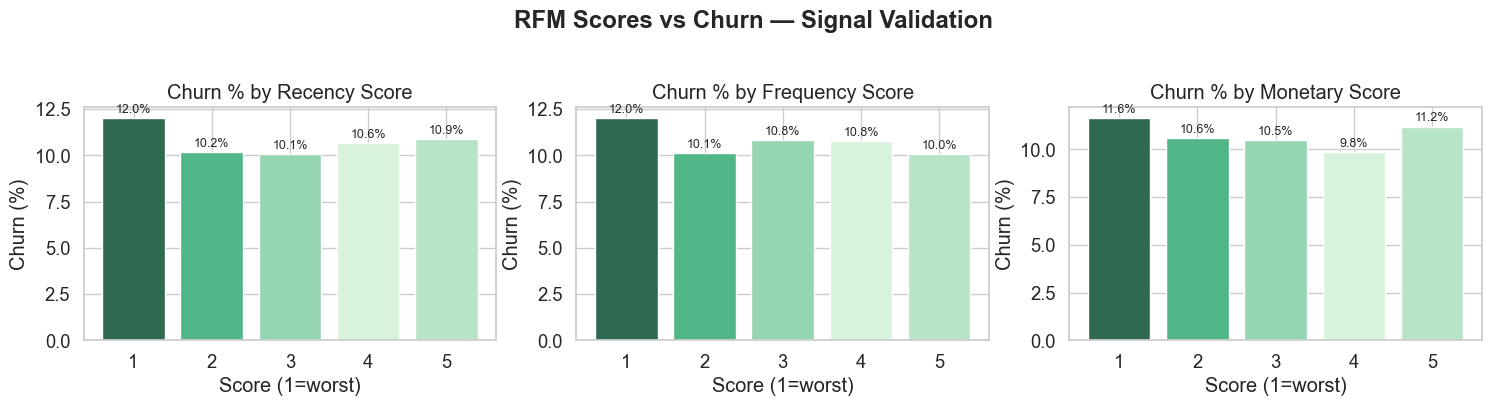

In [7]:
rfm_churn = rfm.merge(eligible, on="user_id", how="left")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ["rfm_recency_score","rfm_frequency_score","rfm_monetary_score"],
    ["Recency","Frequency","Monetary"],
):
    data = rfm_churn.groupby(col)["churned"].mean().mul(100).reset_index()
    bars = ax.bar(data[col].astype(str), data["churned"], color=PALETTE, edgecolor="white")
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, row["churned"] + 0.3,
                f"{row['churned']:.1f}%", ha="center", fontsize=9)
    ax.set(title=f"Churn % by {title} Score", xlabel="Score (1=worst)", ylabel="Churn (%)")

plt.suptitle("RFM Scores vs Churn — Signal Validation", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 4 · Behavioural Features

In [8]:
trip_stats = (trips.groupby("user_id").agg(
    avg_fare       =("fare",            "mean"),
    avg_surge      =("surge_multiplier","mean"),
    tip_rate       =("tip",             lambda x: (x > 0).mean()),
    peak_hour_rate =("hour_of_day",     lambda x: x.isin([7,8,9,17,18,19]).mean()),
    weekend_ratio  =("day_of_week",     lambda x: x.isin(["Saturday","Sunday"]).mean()),
).round(3).reset_index())

trip_stats.head()


,user_id,avg_fare,avg_surge,tip_rate,peak_hour_rate,weekend_ratio
0,R00000,14.642,1.096,0.400,0.200,0.160
1,R00001,12.895,1.071,0.214,0.214,0.286
2,R00002,15.791,1.192,0.208,0.375,0.125
3,R00003,13.497,1.156,0.222,0.111,0.333
4,R00004,16.777,1.262,0.438,0.250,0.438


## Step 5 · Session Engagement Features

In [9]:
session_stats = (sessions.groupby("rider_id").agg(
    session_last_30d        =("session_time", lambda x: (x >= reference_date - pd.Timedelta(days=30)).sum()),
    avg_time_on_app         =("time_on_app",  "mean"),
    session_conversion_rate =("converted",    "mean"),
).round(3).reset_index().rename(columns={"rider_id":"user_id"}))

session_stats.head()


,user_id,session_last_30d,avg_time_on_app,session_conversion_rate
0,R00000,4,92.000,0.25
1,R00001,3,174.667,0.00
2,R00002,3,191.000,0.00
3,R00003,3,75.333,0.00
4,R00004,2,17.000,0.00


## Step 6 · Activity Trend Signal

In [10]:
activity = frequency[["user_id","trips_last_30d","trips_last_60d"]].copy()
activity["activity_trend_30d"] = (activity["trips_last_30d"] / (activity["trips_last_60d"] + 1)).round(3)
activity.head()


,user_id,trips_last_30d,trips_last_60d,activity_trend_30d
0,R00000,1,1,0.500
1,R00001,2,3,0.500
2,R00002,1,4,0.200
3,R00004,2,2,0.667
4,R00005,2,2,0.667


## Step 7 · Assemble Master Feature Table

In [11]:
features = eligible.copy()
features = features.merge(recency[["user_id","days_since_last_trip","days_since_last_session"]], on="user_id", how="left")
features = features.merge(frequency,                             on="user_id", how="left")
features = features.merge(monetary,                              on="user_id", how="left")
features = features.merge(trip_stats,                            on="user_id", how="left")
features = features.merge(session_stats,                         on="user_id", how="left")
features = features.merge(activity[["user_id","activity_trend_30d"]], on="user_id", how="left")
features = features.merge(
    rfm[["user_id","rfm_recency_score","rfm_frequency_score","rfm_monetary_score","rfm_combined_score"]],
    on="user_id", how="left")
features = features.merge(
    riders[["user_id","account_age_days","was_referred","loyalty_status","age","city"]],
    on="user_id", how="left")

features["engagement_score"] = (
    features["rfm_recency_score"]   * 0.40 +
    features["rfm_frequency_score"] * 0.35 +
    features["rfm_monetary_score"]  * 0.25
).round(2)

print(f"Feature table: {features.shape[0]:,} rows × {features.shape[1]} cols")
features.head()


Feature table: 9,204 rows × 31 cols


,user_id,churned,days_since_last_trip,days_since_last_session,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d,monetary_total,monetary_avg,...,rfm_recency_score,rfm_frequency_score,rfm_monetary_score,rfm_combined_score,account_age_days,was_referred,loyalty_status,age,city,engagement_score
0,R00000,0,25,0.0,0,1,1,3,414.13,16.57,...,2,1,4,2.33,93,1,Bronze,35,Nairobi,2.15
1,R00001,1,5,0.0,1,2,3,3,195.69,13.98,...,4,3,1,2.67,230,0,Bronze,35,Nairobi,2.90
2,R00002,1,14,0.0,0,1,4,5,482.94,20.12,...,3,1,5,3.00,232,0,Bronze,47,Lagos,2.80
3,R00004,0,12,0.0,0,2,2,5,391.15,24.45,...,3,3,3,3.00,250,1,Silver,41,Lagos,3.00
4,R00005,0,2,0.0,1,2,2,4,300.63,15.82,...,5,3,2,3.33,657,0,Bronze,40,Lagos,3.55


## Step 8 · Save

In [12]:
out_path = os.path.join(os.path.join("..", "processed"), "features.csv")
features.to_csv(out_path, index=False)
print(f"Saved features.csv  ({len(features):,} rows × {features.shape[1]} cols)")


Saved features.csv  (9,204 rows × 31 cols)
